In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from math import pi

# Create data for all metrics
emotions = ['Anger', 'Calm', 'Disgust', 'Fear', 'Happiness', 'Neutral', 'Sadness', 'Surprise']

# Yadav et al. data
yadav_data = {
    'Accuracy': [85.29, 81.82, 93.55, 70.73, 76.00, 81.58, 83.33, 79.49],
    'Precision': [81.00, 88.00, 88.00, 76.00, 79.00, 61.00, 78.00, 85.00],
    'Recall': [85.00, 82.00, 94.00, 76.00, 79.00, 61.00, 78.00, 85.00],
    'F1-Score': [83.00, 85.00, 91.00, 73.00, 72.00, 61.00, 79.00, 84.00]
}

# Proposed model data
proposed_data = {
    'Accuracy': [83.33, 93.18, 96.88, 75.00, 79.41, 50.00, 79.49, 86.67],
    'Precision': [97.00, 75.00, 91.00, 83.00, 69.00, 83.00, 76.00, 93.00],
    'Recall': [83.00, 93.00, 97.00, 75.00, 79.00, 50.00, 79.00, 87.00],
    'F1-Score': [90.00, 83.00, 94.00, 79.00, 74.00, 62.00, 78.00, 90.00]
}

# Create DataFrames
df_yadav = pd.DataFrame(yadav_data, index=emotions)
df_proposed = pd.DataFrame(proposed_data, index=emotions)

df_yadav['Model'] = 'Yadav et al.'
df_proposed['Model'] = 'Proposed Model'
df_all = pd.concat([df_yadav, df_proposed])



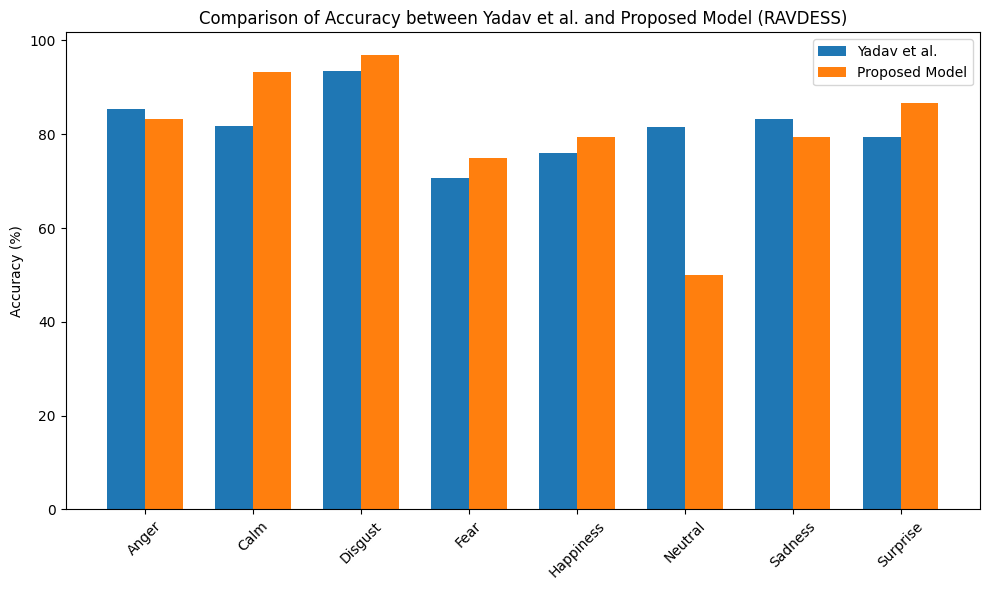

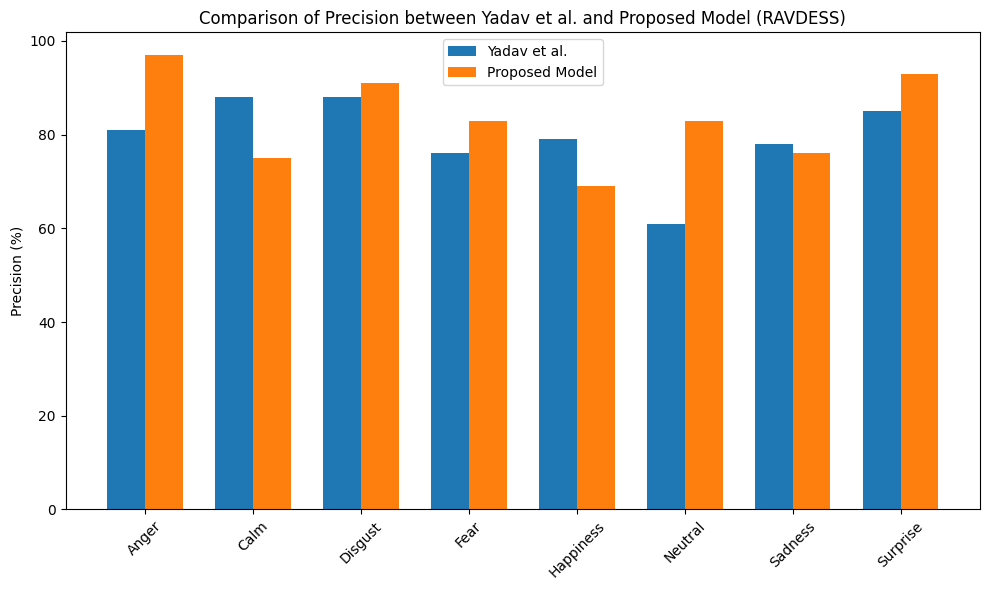

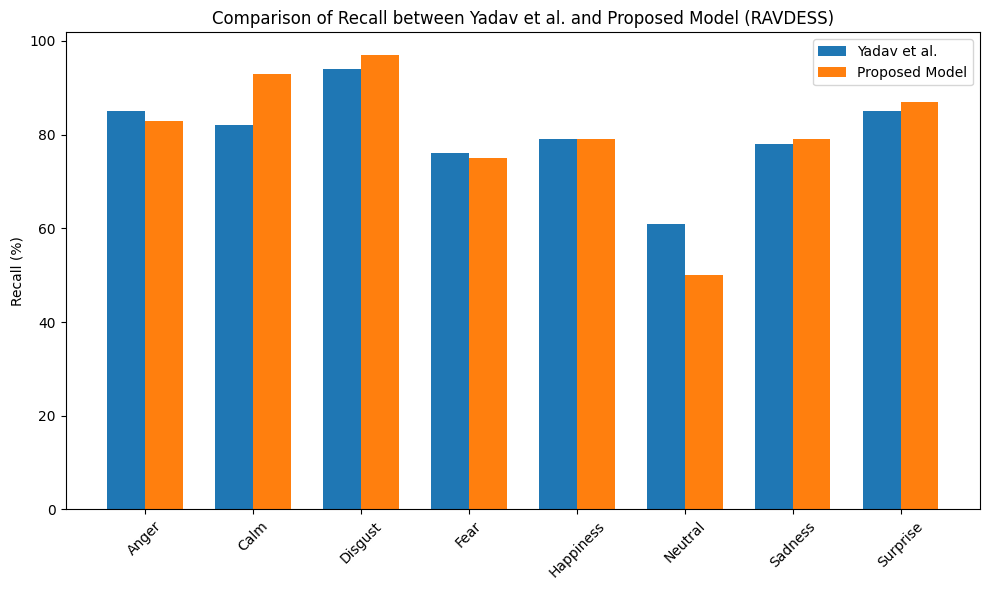

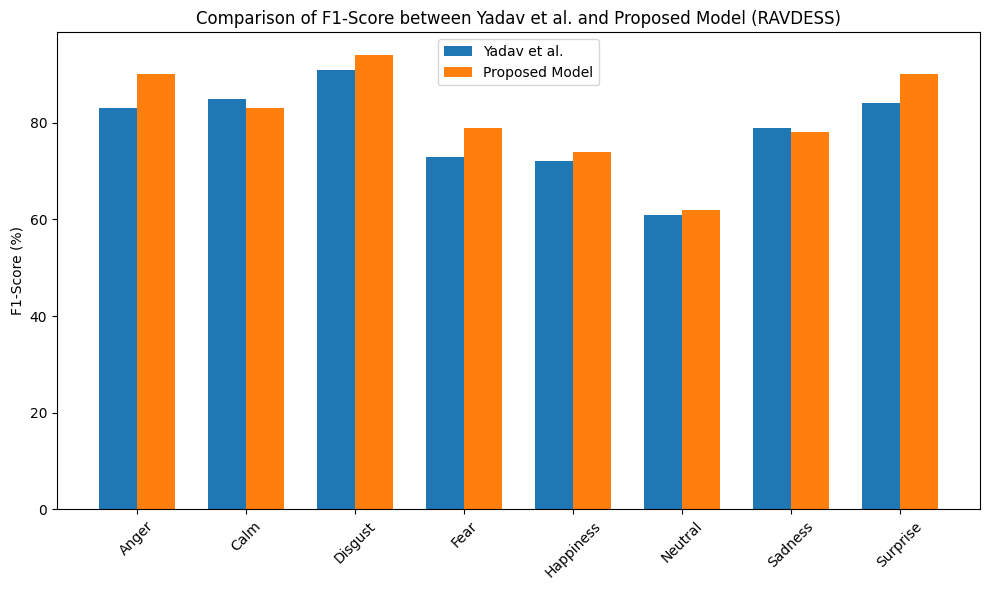

In [2]:
# --- Visualization 1: Grouped Bar Charts ---
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
for metric in metrics:
    plt.figure(figsize=(10, 6))
    bar_width = 0.35
    x = np.arange(len(emotions))
    plt.bar(x - bar_width/2, df_yadav[metric], width=bar_width, label='Yadav et al.')
    plt.bar(x + bar_width/2, df_proposed[metric], width=bar_width, label='Proposed Model')
    plt.xticks(x, emotions, rotation=45)
    plt.ylabel(f'{metric} (%)')
    plt.title(f'Comparison of {metric} between Yadav et al. and Proposed Model (RAVDESS)')
    plt.legend()
    plt.tight_layout()
    plt.show()


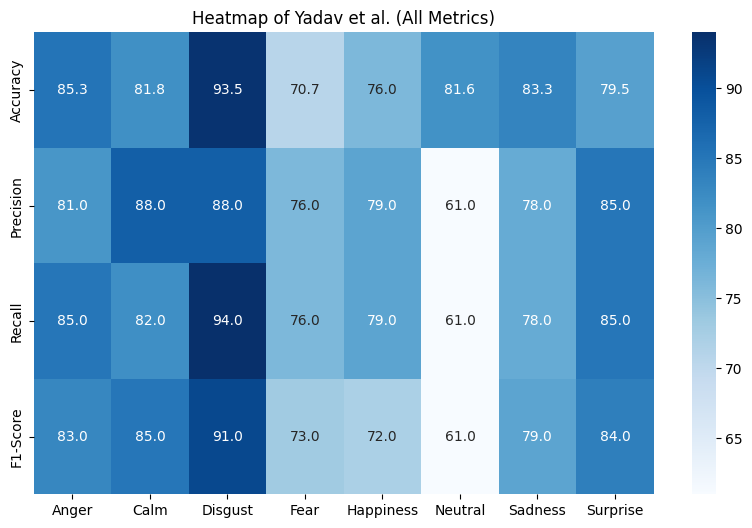

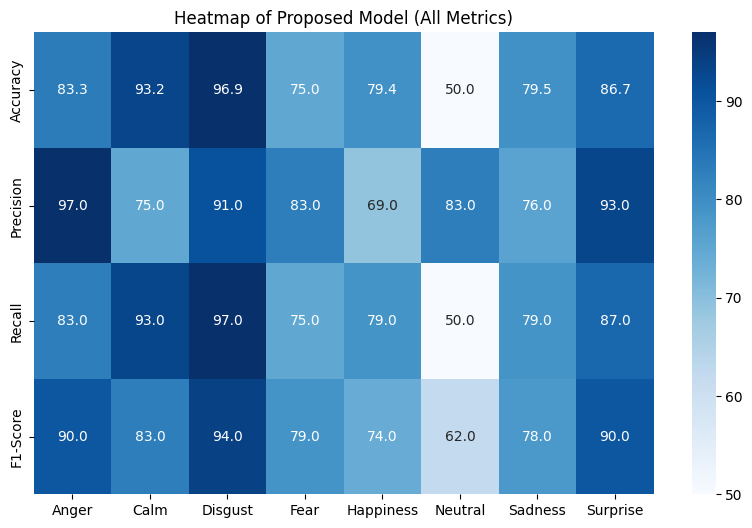

In [4]:

# --- Visualization 2: Heatmap ---
plt.figure(figsize=(10, 6))
sns.heatmap(df_yadav[metrics].T, annot=True, cmap='Blues', fmt='.1f')
plt.title('Heatmap of Yadav et al. (All Metrics)')
plt.show()

plt.figure(figsize=(10, 6))
sns.heatmap(df_proposed[metrics].T, annot=True, cmap='Blues', fmt='.1f')
plt.title('Heatmap of Proposed Model (All Metrics)')
plt.show()


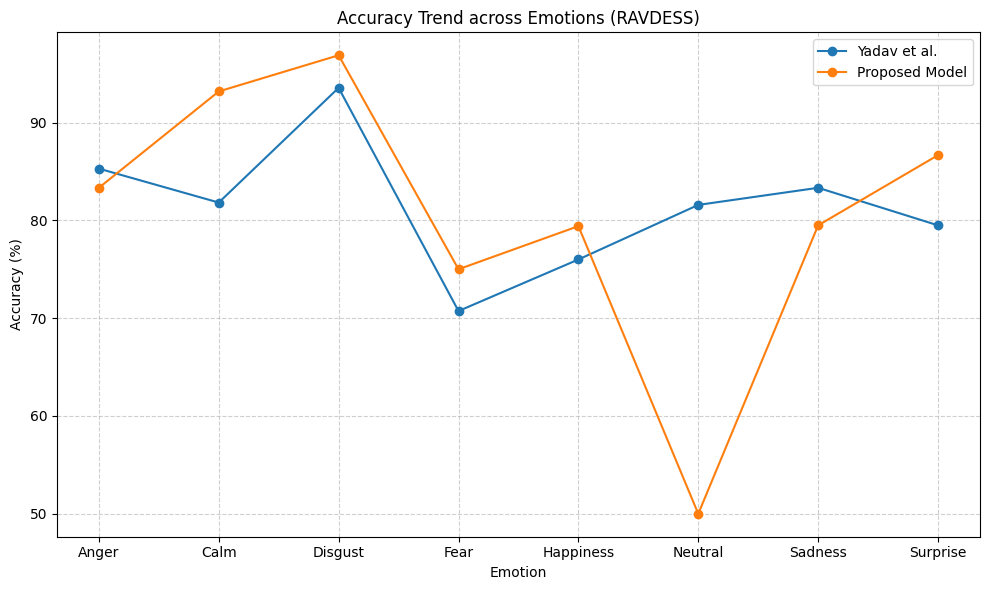

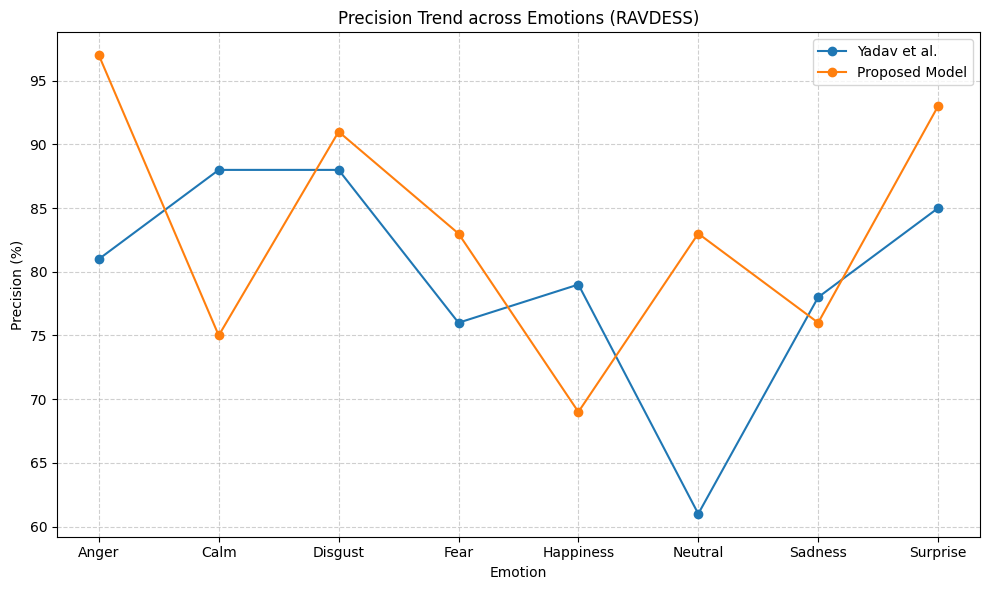

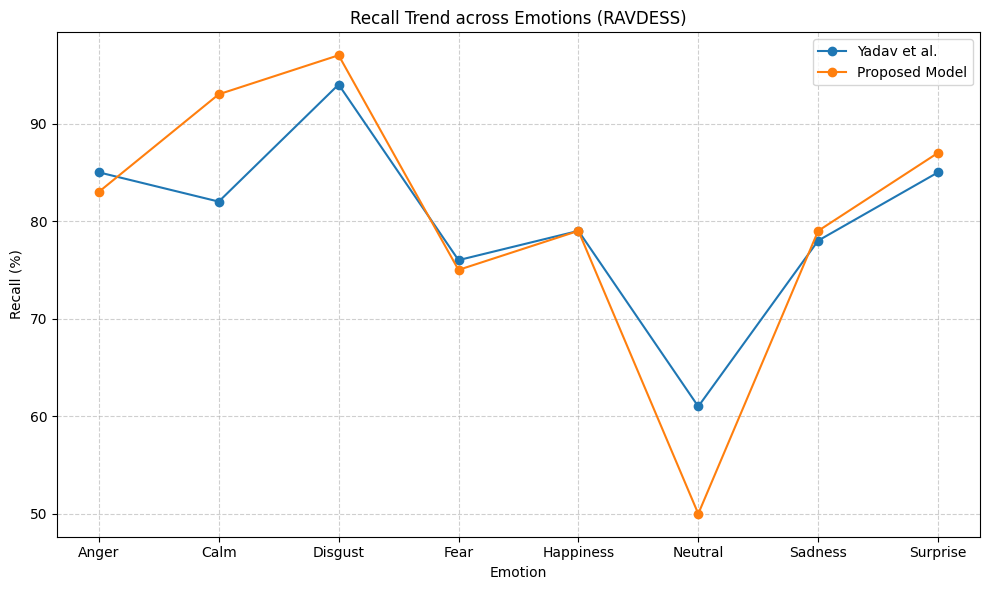

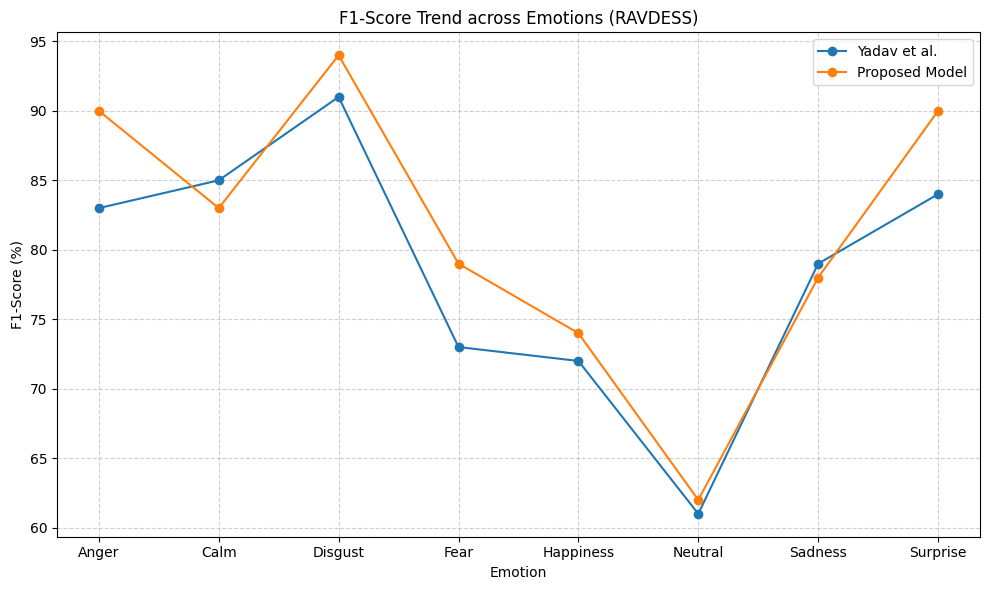

In [5]:

# --- Visualization 3: Line Chart ---
for metric in metrics:
    plt.figure(figsize=(10, 6))
    plt.plot(emotions, df_yadav[metric], marker='o', label='Yadav et al.')
    plt.plot(emotions, df_proposed[metric], marker='o', label='Proposed Model')
    plt.title(f'{metric} Trend across Emotions (RAVDESS)')
    plt.xlabel('Emotion')
    plt.ylabel(f'{metric} (%)')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()



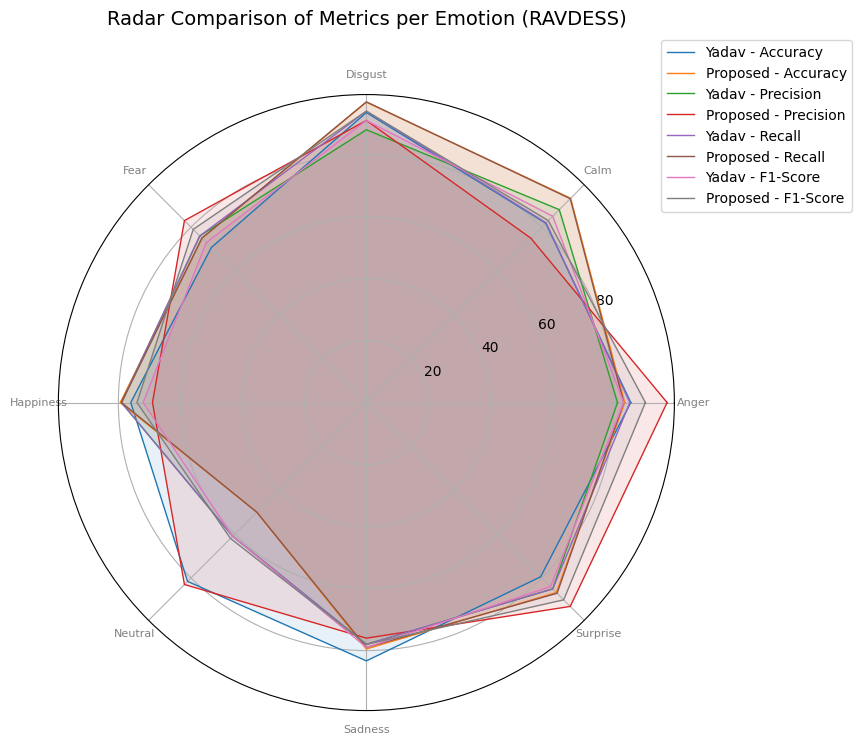

In [6]:
# --- Visualization 4: Radar Chart ---
def make_radar_chart(df1, df2, title):
    categories = list(df1.index)
    N = len(categories)

    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]

    plt.figure(figsize=(8, 8))
    ax = plt.subplot(111, polar=True)
    plt.xticks(angles[:-1], categories, color='grey', size=8)

    for metric in metrics:
        values1 = df1[metric].tolist()
        values1 += values1[:1]
        values2 = df2[metric].tolist()
        values2 += values2[:1]
        ax.plot(angles, values1, linewidth=1, linestyle='solid', label=f'Yadav - {metric}')
        ax.fill(angles, values1, alpha=0.1)
        ax.plot(angles, values2, linewidth=1, linestyle='solid', label=f'Proposed - {metric}')
        ax.fill(angles, values2, alpha=0.1)

    plt.title(title, size=14, y=1.1)
    plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    plt.show()

make_radar_chart(df_yadav, df_proposed, 'Radar Comparison of Metrics per Emotion (RAVDESS)')